#PRESTI LORENZO
#ID:5306189

#SPORTS IMAGES CLASSIFICATION

This project focuses on a classification task using deep learning techniques. The images used for training and evaluation come from https://www.kaggle.com/datasets/sovitrath/sports-image-dataset. For my analysis, I selected 12 sports categories from those available in the dataset.

The first step involves verifying the integrity of the images—checking whether all files are usable and removing any that do not meet the necessary criteria for analysis. To ensure variability and avoid bias, each time the code is executed, a random selection of 250 images is drawn from the folders containing only the valid images for the chosen sports categories. This approach helps maintain a balanced and diverse training dataset while preventing overfitting.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
resources = "drive/MyDrive/Colab Notebooks/RISORSE"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install d2l

In [ ]:
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils import data
from d2l import torch as d2l
import numpy as np
import matplotlib.pyplot as plt
d2l.use_svg_display()
import os
import random
import shutil
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch import nn
from torch.nn import functional as F
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import torchvision.models as models
import torch.optim as optim

#DATA EXPLORATORY ANALYSIS
First I upload the dataset and print all the selected classes with their respective dimensions. Then I'll proceed by checking if all the values are usable and not corrupted, the non-usable or corrupted ones are going to be discarded.

In [ ]:
dataset_path = "/content/drive/My Drive/proj_dataset"
print("Path to dataset files:", dataset_path)
class_ct = {}
for c_name in os.listdir(dataset_path):
    c_path = os.path.join(dataset_path, c_name)
    if os.path.isdir(c_path):
        class_ct[c_name] = len(os.listdir(c_path))

print(class_ct)

Path to dataset files: /content/drive/My Drive/proj_dataset
{'fencing': 626, 'motogp': 669, 'baseball': 726, 'basketball': 485, 'formula1': 677, 'tennis': 707, 'ice_hockey': 701, 'football': 790, 'swimming': 681, 'boxing': 695, 'wrestling': 599, 'volleyball': 699}


In [ ]:
def check_dataset_integrity(dataset_path):

    problematic_files = []
    for root, _, files in os.walk(dataset_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                # Attempt to open the file as an image
                with Image.open(file_path) as img:
                    img.verify()  # Verify the file is an image
            except Exception as e:
                problematic_files.append(file_path)
                print(f"File {file_path} is problematic: {e}")
    return problematic_files

# Run the check
issues = check_dataset_integrity(dataset_path)
if not issues:
    print("All files are valid.")
else:
    print(f"Found {len(issues)} problematic files.")

All files are valid.


In [ ]:
def remove_problematic_files(problematic_files):
    for file_path in problematic_files:
        try:
            os.remove(file_path)
            print(f"Removed: {file_path}")
        except Exception as e:
            print(f"Failed to remove {file_path}: {e}")

# Remove problematic files
remove_problematic_files(issues)

Now, the code will randomly select 250 images from each folder corresponding to the chosen sports categories. To verify that the selection process has been executed correctly, I will display three sample images from each class. This will help ensure that the dataset is properly loaded and that the images are distributed as expected.

In [ ]:
# Percorso al nuovo dataset ridimensionato
resized_dataset_path = "/content/dataset_resized"
os.makedirs(resized_dataset_path, exist_ok=True)

# Numero di immagini per classe
target_count = 250

# Itera su ciascuna classe
for c_name in os.listdir(dataset_path):
    c_path = os.path.join(dataset_path, c_name)

    # Controlla se è una directory
    if os.path.isdir(c_path):
        # Crea la cartella per la classe nel dataset ridimensionato
        new_c_path = os.path.join(resized_dataset_path, c_name)
        os.makedirs(new_c_path, exist_ok=True)

        # Ottieni una lista di immagini nella classe
        images = os.listdir(c_path)
        images = [img for img in images if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Seleziona casualmente target_count immagini
        selected_images = random.sample(images, min(len(images), target_count))

        # Copia le immagini selezionate nella nuova directory
        for img in selected_images:
            src_path = os.path.join(c_path, img)
            dst_path = os.path.join(new_c_path, img)
            shutil.copy(src_path, dst_path)

        print(f"Classe {c_name}: {len(selected_images)} immagini copiate.")


Classe fencing: 250 immagini copiate.
Classe motogp: 250 immagini copiate.
Classe baseball: 250 immagini copiate.
Classe basketball: 250 immagini copiate.
Classe formula1: 250 immagini copiate.
Classe tennis: 250 immagini copiate.
Classe ice_hockey: 250 immagini copiate.
Classe football: 250 immagini copiate.
Classe swimming: 250 immagini copiate.
Classe boxing: 250 immagini copiate.
Classe wrestling: 250 immagini copiate.
Classe volleyball: 250 immagini copiate.


Classe: wrestling


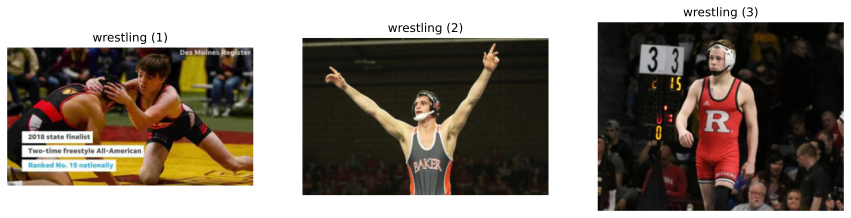

Classe: basketball


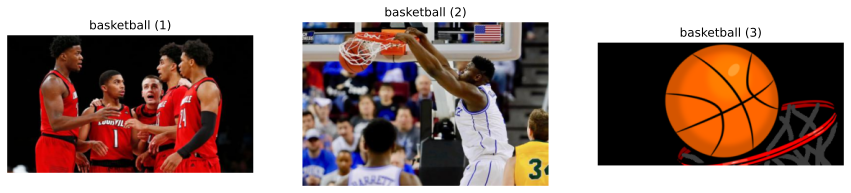

Classe: football


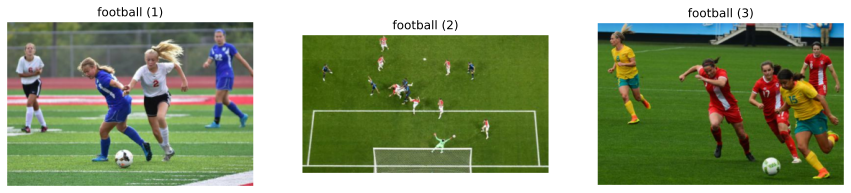

Classe: fencing


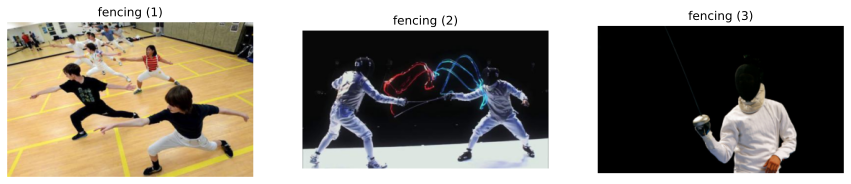

Classe: volleyball


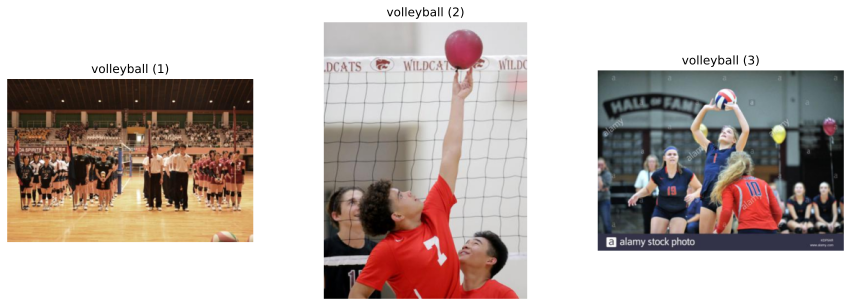

Classe: formula1


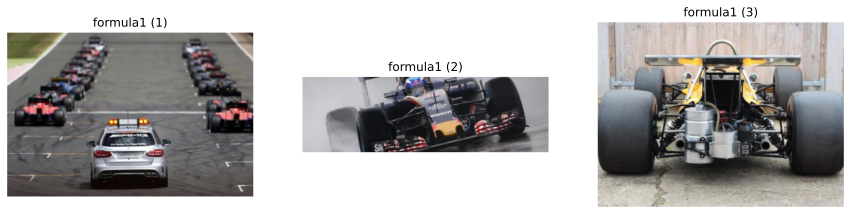

Classe: motogp


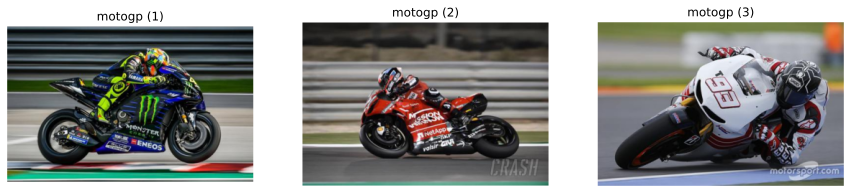

Classe: tennis


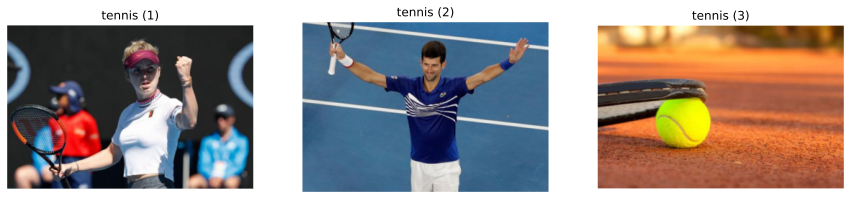

Classe: ice_hockey


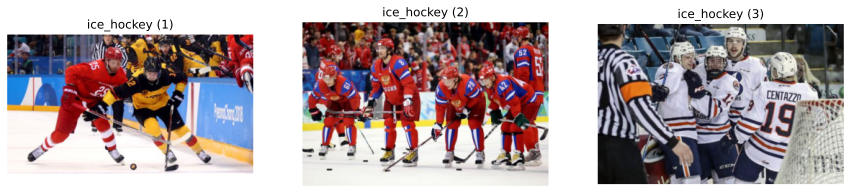

Classe: boxing


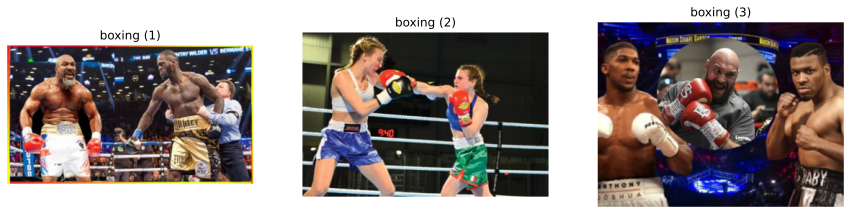

Classe: baseball


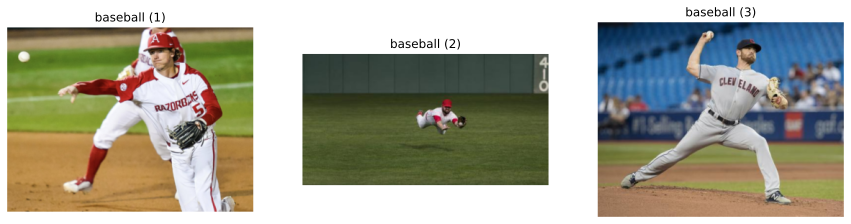

Classe: swimming


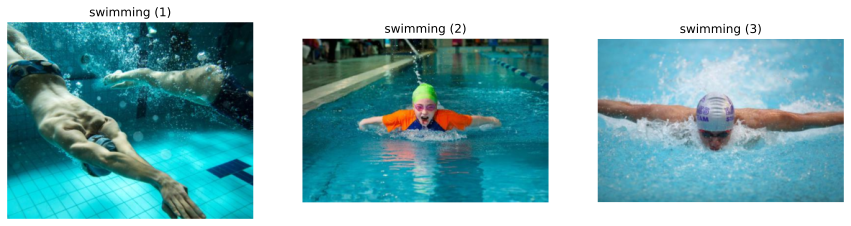

In [ ]:
def display_sample_images(data_folder, num_images=3):

    # Ottieni le classi come sottodirectory del dataset
    classes = [d for d in os.listdir(data_folder) if os.path.isdir(os.path.join(data_folder, d))]

    for c_name in classes:
        c_path = os.path.join(data_folder, c_name)
        images = [img for img in os.listdir(c_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Seleziona immagini casuali dalla classe
        sample_images = random.sample(images, min(num_images, len(images)))

        print(f"Classe: {c_name}")
        plt.figure(figsize=(15, 5))  # Dimensione della figura

        for i, img_name in enumerate(sample_images):
            img_path = os.path.join(c_path, img_name)
            img = Image.open(img_path)

            plt.subplot(1, num_images, i + 1)  # Organizza le immagini su una riga
            plt.imshow(img)
            plt.title(f"{c_name} ({i + 1})")  # Aggiungi titolo con il nome della classe
            plt.axis('off')  # Nascondi assi

        plt.show()

# Visualizza un campione di immagini (3 immagini per classe)
display_sample_images(resized_dataset_path, num_images=3)


In [ ]:
def check_image_sizes(main_folder):
    size_counts = {}
    for c_name in os.listdir(main_folder):
        c_path = os.path.join(main_folder, c_name)
        if os.path.isdir(c_path):
            for img_name in os.listdir(c_path):
                img_path = os.path.join(c_path, img_name)

                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    try:
                        with Image.open(img_path) as img:
                            size = img.size
                            if size in size_counts:
                                size_counts[size] += 1
                            else:
                                size_counts[size] = 1
                    except Exception as e:
                        print(f"Errore nell'aprire il file {img_path}: {e}")

    for size, count in size_counts.items():
        print(f"Risolution {size}: {count} images")

check_image_sizes(resized_dataset_path)

Risolution (500, 330): 9 images
Risolution (500, 262): 73 images
Risolution (500, 315): 6 images
Risolution (499, 269): 2 images
Risolution (499, 281): 52 images
Risolution (500, 333): 759 images
Risolution (500, 300): 23 images
Risolution (318, 500): 3 images
Risolution (500, 375): 238 images
Risolution (500, 281): 735 images
Risolution (480, 360): 19 images
Risolution (500, 306): 6 images
Risolution (400, 300): 19 images
Risolution (400, 267): 17 images
Risolution (499, 241): 4 images
Risolution (500, 449): 2 images
Risolution (500, 319): 7 images
Risolution (332, 500): 5 images
Risolution (325, 217): 4 images
Risolution (490, 500): 3 images
Risolution (500, 284): 4 images
Risolution (499, 333): 50 images
Risolution (500, 344): 3 images
Risolution (500, 331): 34 images
Risolution (500, 400): 18 images
Risolution (499, 161): 1 images
Risolution (500, 271): 10 images
Risolution (500, 360): 8 images
Risolution (300, 252): 1 images
Risolution (300, 225): 11 images
Risolution (330, 500): 

#IMAGES PRE-PROCESSING

The original images in the dataset have varying dimensions, so to ensure consistency, I standardized their size by resizing all images to 500x333. This resolution was chosen because it was the most common size in the dataset, and most images had similar aspect ratios.

After resizing, I converted all images into PyTorch tensors and loaded the transformed dataset into batches of 64 images per batch. To normalize the dataset, I computed the mean and standard deviation for each color channel (RGB) by:

      1. Calculating the mean pixel values across height, width, and batch for each channel.

      2. Storing the total number of images processed (num_img).
      
      3. Computing the global mean and standard deviation by dividing the accumulated sums by the total number of images.

This preprocessing step ensures that the input data is well-scaled for training, improving the model's stability and convergence.

In [ ]:
# Crea una trasformazione per il dataset
transform = transforms.Compose([
    transforms.Resize((500, 333)),
    transforms.ToTensor()
])

# Usa il dataset ImageFolder di PyTorch (o uno personalizzato)
dataset = datasets.ImageFolder(resized_dataset_path, transform=transform)

# Crea un DataLoader per caricare il dataset in batch
data_loader = DataLoader(dataset, batch_size=64, shuffle=False)

# Variabili per sommare media e deviazione standard
mean_sum = torch.zeros(3)
std_sum = torch.zeros(3)
num_img = 0

# Calcola media e deviazione standard per batch
for images, _ in data_loader:
    # Somma la media e deviazione standard per batch
    mean_sum += images.mean(dim=[0, 2, 3]) * images.size(0)
    std_sum += images.std(dim=[0, 2, 3]) * images.size(0)
    num_img += images.size(0)

# Calcola la media e deviazione standard globali
mean = mean_sum / num_img
std = std_sum / num_img

# Stampa i risultati
print(f"Mean: {mean}")
print(f"Standard deviation:{std}")

Mean: tensor([0.4428, 0.4357, 0.4166])
Standard deviation:tensor([0.2940, 0.2733, 0.2773])


# DATA AUGUMENTATION
To improve model generalization and robustness, I applied data augmentation to introduce controlled variations in the training images. These transformations help the model learn more diverse features and prevent overfitting by simulating real-world variations.

For this project, I used the following augmentations, each applied with a 50% probability (p=0.5):

    -Resizing to 500x333 → Standardizes image dimensions across the dataset (if by any chance that some images still have different sizes, keeping the resize step ensures consistency).
    -Random Rotation (±30 degrees) → Simulates different viewing angles.
    -Random Horizontal Flip → Helps the model recognize features regardless of left-right orientation.
    -Random Vertical Flip → Introduces variations for images where orientation may not be fixed.
    -Color Jitter (brightness ±30%, contrast ±10%, saturation ±20%, hue ±10%) → Introduces small color variations to improve adaptability to lighting conditions.
    -Gaussian Blur (kernel size=3, sigma=0.1 to 2.0) → Mimics different levels of focus and sharpness, improving generalization.
    -RandomAffine: Adds small rotations, translations, and scaling to simulate different angles.
    -RandomPerspective: Warps the image to create different viewpoints
    -Conversion to PyTorch Tensor → Transforms images into tensors for deep learning processing.
    -Normalization (Mean: [0.4403, 0.4332, 0.4148], Std: [0.2959, 0.2754, 0.2801]) → Standardizes pixel values based on computed dataset statistics.

For validation and testing, I applied only resizing, tensor conversion, and normalization, ensuring that test images remain unchanged for fair model evaluation.

In [ ]:
mean=torch.tensor([0.4403, 0.4332, 0.4148])
stdev=torch.tensor([0.2959, 0.2754, 0.2801])
data_augmentation = transforms.Compose([
    transforms.Resize((500, 333)),
    transforms.RandomApply([transforms.RandomRotation(degrees=30)], p=0.5),
    transforms.RandomApply([transforms.RandomHorizontalFlip(p=1.0)], p=0.5),
    transforms.RandomApply([transforms.RandomVerticalFlip(p=1.0)], p=0.5),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=0.1, saturation=0.2, hue=0.1)], p=0.5),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.5),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=10),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=stdev),
    transforms.RandomErasing(p=0.5),
])

test_augmentation = transforms.Compose([
    transforms.Resize((500, 333)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=stdev)
])

To improve training robustness, I created a custom dataset class called SportsDataset, which introduces oversampling to balance the dataset and improve model generalization.

This class extends torch.utils.data.Dataset and provides additional functionality:

    -__len__ function → Redefines the total number of samples by multiplying the dataset size by the oversampling factor.

    -__getitem__ function → Retrieves a sample from the dataset and applies the specified transformations. The modulo operation (idx % len(self.dataset)) ensures that we cycle through the dataset multiple times to simulate a larger training set.

    -Transformation Handling → If the image is not already a PyTorch tensor, the specified transformations are applied before returning the processed image and its label.

By using this oversampling technique, the dataset effectively increases the exposure of training samples, helping the model generalize better and ensures that training is more stable and robust.

In [ ]:
class SportsDataset(data.Dataset):
    def __init__(self, dataset, transform=None, oversample=5):
        self.dataset = dataset
        self.transform = transform
        self.oversample = oversample

    def __len__ (self):
        return len(self.dataset) * self.oversample

    def __getitem__(self, idx):
        # Use modulo to get the original image
        original_idx = idx % len(self.dataset)
        image, label = self.dataset[original_idx]

        if not isinstance(image, torch.Tensor) and self.transform:
            image = self.transform(image) # Apply transforms only if not already a tensor

        return image, label

#AUGUMENTED IMAGES
To verify that data augmentation is applied correctly, I implemented a function to denormalize and visualize a batch of images from the dataset.
First I creates the Augmented Dataset (the ImageFolder dataset (new_dataset) is initialized with data_augmentation to apply transformations), then I extracted a Batch of Images (a sample of 30 images selected from new_dataset), finally I created an Image Grid (with images arranged in a 5-column grid by using torchvision.utils.make_grid()).

To display the Image Grid I used the matplotlib library to visualize the augmented images.

In order to do the Denormalization i used the imshow function which reverts the normalization process (img = img * std + mean) to restore original pixel values, uses torch.clamp() to ensure pixel values remain within the valid range [0,1][0,1]and converts the tensor to a NumPy array and rearranges dimensions for display.

This step helps to confirm that the data augmentation is applied as expected before training, allowing us to inspect the transformations visually.

In [ ]:
new_dataset = datasets.ImageFolder(root=resized_dataset_path, transform=data_augmentation)

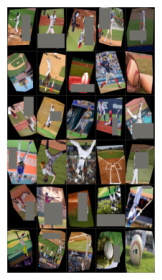

In [ ]:
def imshow(img, mean, std):
    # Converti mean e std in tensori solo se sono liste
    mean = torch.tensor(mean)[:, None, None] if isinstance(mean, list) else mean
    std = torch.tensor(std)[:, None, None] if isinstance(std, list) else std

    # Denormalizzazione
    img = img * std + mean
    img = torch.clamp(img, 0, 1)  # Clipping dei valori per rimanere nel range [0, 1]

    # Converti in formato NumPy e cambia la disposizione degli assi
    np_img = img.numpy()
    plt.imshow(np.transpose(np_img, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Valori di mean e std per la normalizzazione
mean = [0.4418, 0.4327, 0.4148]
stdev = [0.2947, 0.2738, 0.2784]

# Ottieni un batch di immagini da `new_dataset`
images = [new_dataset[i][0] for i in range(30)]  # Modifica `new_dataset` come necessario

# Crea una griglia di immagini
grid_img = torchvision.utils.make_grid(images, nrow=5)

# Visualizza la griglia
imshow(grid_img, mean, stdev)


# DENSENET ARCHITECTURE

Now i defined a fine-tuned DenseNet-121 model for my class classification task. The model leverages transfer learning by using a pretrained DenseNet-121 from torchvision.models, which has been trained on ImageNet. Moreover I decided to incorporate dropout for regularization and overfitting prevention.

The code initializes a pretrained DenseNet-121 from torchvision.models, the pretrained weights come from ImageNet, allowing the model to utilize general visual features learned from a massive dataset; I decided to use DenseNet-121 because of its dense connectivity, which allows more efficient gradient flow and feature reuse compared to architectures like ResNet, since the early layers capture general patterns I decided to freeze them to retain pre-trained knowledge this is useful to prevent overfitting and saving memory, making the model more efficient for training.

The only trainable layers are  the last dense block (denseblock4) which is fine-tuned to adapt the model to new data and the final layer (classifier)which is replaced to match the new dataset with 12 classes since DenseNet-121 was originally trained on 1,000 ImageNet classes.

Finally I decided to perform a Test Forward Pass in order to confirm that the network is correctly structured before training.

In [ ]:
class FineTunedDenseNet121(nn.Module):
    def __init__(self, num_classes=12, dropout_prob=0.5):
        super(FineTunedDenseNet121, self).__init__()

        # ✅ Load Pretrained DenseNet121
        self.densenet = models.densenet121(pretrained=True)

        # ✅ Freeze earlier layers (fine-tune only `denseblock4` and classifier)
        for name, param in self.densenet.named_parameters():
            if "denseblock4" in name or "classifier" in name:
                param.requires_grad = True  # Fine-tune last block & classifier
            else:
                param.requires_grad = False  # Freeze earlier layers

        # ✅ Replace classifier with a new FC layer
        in_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Sequential(
            nn.Dropout(p=dropout_prob),  # Add dropout to prevent overfitting
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.densenet(x)  # Pass input through DenseNet121

# ✅ Check if the model works
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FineTunedDenseNet121(num_classes=12, dropout_prob=0.5).to(device)

# Test forward pass with random input
X = torch.randn(8, 3, 64, 64).to(device)
output = model(X)
print("Output shape:", output.shape)  # Expected: (8, 12)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Output shape: torch.Size([8, 12])


#MODEL TRAINING AND EVALUATION

Now i want to train and evaluate a neural network efficiently while making sure to get the best possible model.

First, we have the accuracy evaluation function (evaluate_accuracy_gpu). This one runs the model on a dataset (like validation or test data), counts how many predictions it gets right (the accumulator tracks the number of corrected predictions and the total number of predictions), and then gives us an accuracy percentage. To speed things up, it moves everything to the GPU if available.

Now, onto the training function, which fine-tunes DenseNet-121 while ensuring efficient optimization.

-Setting Up the Model for Training: the model is moved to the GPU for faster processing. The loss function (CrossEntropyLoss()) is selected, which is ideal for multi-class classification tasks.

-Choosing the Optimizer & Learning Rate Scheduler: Adam optimizer is used because it dynamically adjusts learning rates, making training more efficient.
-The learning rate scheduler (StepLR) is applied to gradually reduce the learning rate, preventing oscillations and helping the model converge.

-Tracking Training Progress:a progress bar (tqdm) is used to monitor training across multiple epochs.

-Computing Accuracy & Loss: after each batch, training accuracy and loss are logged to monitor progress. At the end of the epoch, validation accuracy is computed using evaluate_accuracy_gpu().

-Saving the Best Model: the model is saved only if validation accuracy improves, ensuring we keep the best-performing version.

-At the end of training, it prints out the final accuracy and tells us how fast it processed the data.

In [ ]:
def evaluate_accuracy_gpu(net, data_iter, device=None):
    net.eval()  # Set model to evaluation mode
    if not device:
        device = next(iter(net.parameters())).device

    correct, total = 0, 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            preds = torch.argmax(y_hat, dim=1)  # Get predicted class
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total  # Return computed accuracy


# Training Function for Fine-Tuning
def train(net, train_iter, val_iter, num_epochs, optimizer, scheduler, device, save_path="best_model_dn.pth"):
    print(f'Training on {device}')
    net.to(device)

    loss_fn = nn.CrossEntropyLoss()
    best_val_acc = 0
    progress_bar = tqdm(range(num_epochs))

    # ✅ Add lists to track metrics
    train_losses, train_accuracies, val_accuracies = [], [], []

    for epoch in progress_bar:
        net.train()
        running_loss, correct, total = 0, 0, 0

        for X, y in train_iter:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            y_hat = net(X)
            loss = loss_fn(y_hat, y)
            loss.backward()
            optimizer.step()

            # Compute batch accuracy
            preds = torch.argmax(y_hat, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            running_loss += loss.item() * X.size(0)


        train_loss = running_loss / total
        train_acc = correct / total
        val_acc = evaluate_accuracy_gpu(net, val_iter, device)


        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        #Save the best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': train_loss,
            }, save_path)

        scheduler.step()

        #Progress bar update
        progress_bar.set_description(f'Epoch {epoch+1}: loss {train_loss:.3f}, train acc {train_acc:.3f}, val acc {val_acc:.3f}, best val acc {best_val_acc:.3f}')

    print(f'Final Training Loss: {train_loss:.3f}, Training Accuracy: {train_acc:.3f}')
    print(f'Best Validation Accuracy: {best_val_acc:.3f}')

    # Quick plot after training
    plt.plot(train_losses, label="train loss", color="blue")
    plt.plot(train_accuracies, label="train acc", linestyle="dashed", color="magenta")
    plt.plot(val_accuracies, label="val acc", linestyle="dashdot", color="green")
    plt.xlabel("Epochs")
    plt.ylabel("Loss / Accuracy")
    plt.legend()
    plt.title("Training Progress")
    plt.grid(True)
    plt.show()




In [ ]:
torch.cuda.is_available() #Check for GPU availability

True

#DATA SPLITTING AND DATA LOADING

To ensure a consistent and reproducible training process, I set a random seed (42) across Python, NumPy, and PyTorch. This makes sure that the dataset split and model training produce the same results every time.

Now I split the dataset into training, validation and test subsets (a 70-30 split , the test set is further divided into validation (50%) and test (50%)), incorporating reproducibility, data augmentation, and dataset statistics.


DataLoaders:

-The training set is shuffled (so the model doesn't see images in a fixed order).
-The validation and test sets aren't shuffled since order doesn't really matter there.
-Batch size is 16, meaning the model processes 16 images at a time to keep things efficient.

To double-check that everything is working, I printed the first batch from the training set. It showed the shape of the images and their corresponding labels—so I know everything is loading properly, finally to add one last check I'll also graphically inspect a batch to ensure that the data augmentation pipeline is functioning as expected and that images are properly transformed.

In [ ]:
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)


train_dataset, test_dataset = train_test_split(new_dataset, test_size=0.3, random_state=SEED)
test_dataset, val_dataset = train_test_split(test_dataset, test_size=0.5, random_state=SEED)
train_dataset = SportsDataset(train_dataset, transform=data_augmentation, oversample=1)
test_dataset = SportsDataset(test_dataset, transform=test_augmentation, oversample=1)
val_dataset = SportsDataset(val_dataset, transform=test_augmentation, oversample=1)
train_size = len(train_dataset)
val_size = len(val_dataset)
test_size = len(test_dataset)
total_size = train_size + val_size + test_size


print(f"Training examples: {train_size}")
print(f"Validation examples: {val_size}")
print(f"Testing examples: {test_size}")

Training examples: 3395
Validation examples: 728
Testing examples: 728


In [ ]:
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

for images, labels in train_loader:
    print(f"Batch shape: {images.size()}")
    print(f"Labels: {labels}")
    break

Batch shape: torch.Size([16, 3, 500, 333])
Labels: tensor([11,  7,  9,  3,  9,  8,  7,  5, 10,  0,  4,  6,  3,  0,  2,  0])


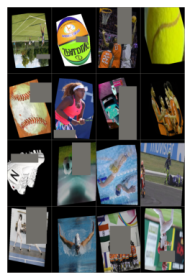

In [ ]:
images = next(iter(train_loader))[0][:16]
grid_img = torchvision.utils.make_grid(images, nrow=4)
imshow(grid_img, mean, stdev)

#MODEL TRAIN AND EVALUATION
Now it's time to train the model.

But before I need to set up the DenseNet-121 model for fine-tuning, first of all I create the the DenseNet-121 model (FineTunedDenseNet121), modified for 12-class classification, using dropout (0.5) to prevent overfitting.

Then I defined the optimizer, I'm using Adam optimizer because it automatically adjusts learning rates for efficient training, i chose to give learning rates for different layers:

-DenseBlock4 (lr=1e-4): Fine-tuned slowly to preserve pre-trained knowledge.

-Classifier (lr=1e-3): Trains faster since it's newly added and requires more updates.

This helps prevent catastrophic forgetting while allowing the classifier to adapt quickly.

Then I set up the learning rate scheduler, which reduces the learning rate every 5 epochs (step_size=5) to refine weight updates, moreover it multiplies the learning rate by 0.5 (gamma=0.5) when the step occurs (every 5 epochs), this is done by the StepLR function.

This prevents the model from taking large jumps in optimization, improving stability.

After the training is run the model makes predictions, and I take the class with the highest probability (argmax()) for each image, I also keep track of the actual labels to be able to compare them later.

Once all predictions are made, I calculate the accuracy score, this tells me the percentage of correctly classified images, to get more detailed insights, I generate a confusion matrix, which shows where the model made mistakes (I can choose a normalized version (where values represent proportions) or an unnormalized version (showing raw counts).
This helps identify which sports categories might be getting misclassified).

Finally I can plot the confusion matrix so I can visually spot patterns—like which categories the model confuses the most.

At the end we'll have:

-Overall accuracy to see how well the model performed.

-A classification report that breaks down precision, recall, and F1-score for each class.

        

Training on cuda


Epoch 10: loss 0.106, train acc 0.973, val acc 0.860, best val acc 0.860: 100%|██████████| 10/10 [08:11<00:00, 49.19s/it]

Final Training Loss: 0.106, Training Accuracy: 0.973
Best Validation Accuracy: 0.860


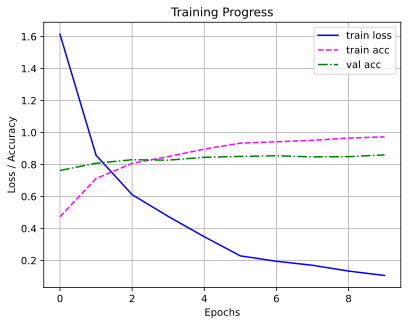

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FineTunedDenseNet121(num_classes=12, dropout_prob=0.5).to(device)

#Define Optimizer
optimizer = optim.Adam([
    {"params": model.densenet.features.denseblock4.parameters(), "lr": 1e-4},  # Fine-tune last DenseNet block
    {"params": model.densenet.classifier.parameters(), "lr": 1e-3}    # Train FC layer faster
])

#Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

#Train the Model
num_epochs = 10
train(model, train_loader, val_loader, num_epochs, optimizer, scheduler, device=device)


In [ ]:
Y_true = []
Y_pred = []
for X, y in test_loader:
    X = X.to(device)
    y = y.to(device)
    y_hat = model(X)
    Y_pred.extend(torch.argmax(y_hat, dim=1).cpu().numpy())
    Y_true.extend(y.cpu().numpy())

accuracy:  0.8653846153846154


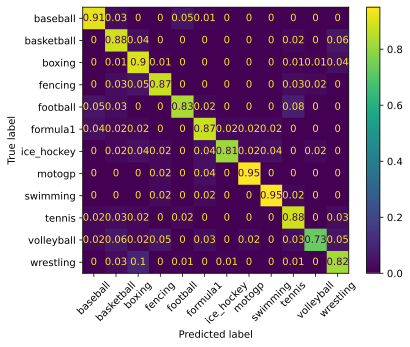

In [ ]:
acc = accuracy_score(Y_true, Y_pred)
conf_mat = confusion_matrix(Y_true, Y_pred, normalize='true') #For Normalized Confusion Matrix
#conf_mat = confusion_matrix(Y_true, Y_pred) #For Unnormalized Confusion Matrix
report = classification_report(Y_true, Y_pred, target_names=new_dataset.classes)
conf_mat = np.round(conf_mat, 2)
disp = ConfusionMatrixDisplay(conf_mat, display_labels=new_dataset.classes)
disp.plot(xticks_rotation=45)
print("accuracy: ", acc)

The confusion matrix displayed reveals the following observations about the model's performance:

    Class-Level Insights:
        The model performs exceptionally well for all classes, in this particular run we are achieving true positive rates of above 0.8 for every class except "volleyball" which has a true positive rates of 0.73 (still quite good). Overall running the model a few times (since every run takes 250 random images for class, the results will be different) I could notice that the true positive rate for a single class never gets lower than 0.65, this indicates that the model has learned to recognize the class effectively.

    Confusion and Misclassifications:
        Even if the model performs well, sometimes classes exhibit confusion with each other. This could be due to similar feature representations in the dataset or insufficient diversity in training data for these classes.
        Classes with higher confusion indicate that the model might be relying on shared features (e.g., uniforms or environments) that are not distinctive enough.

    Overall Accuracy:
        In all different runs the accuracy value always stands between 80% and 90%, in this run particularly the model achieved an accuracy of approximately 86.54%, which suggests great success in classifying the dataset but leaves some room for improvement.
